In [5]:
# Output:
# 1) Stratified CV F1_macro
# 2) GroupKFold by region F1_macro
# 3) Holdout metrics + confusion matrix
# 4) Permutation importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

C:\Users\Zepspel\AppData\Local\Temp\ipykernel_11316\2004235427.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(CSV_PATH)


Classes: ['control', 'endo', 'exo']
Samples: 61950 | Spectrum points: 1015 | Unique regions: 7
Feature matrix: (61950, 1178)

Holdout (stratified) metrics:
Accuracy: 0.837616
F1 macro: 0.836261
              precision    recall  f1-score   support

     control       0.83      0.83      0.83      5250
        endo       0.82      0.81      0.81      4725
         exo       0.86      0.87      0.87      5513

    accuracy                           0.84     15488
   macro avg       0.84      0.84      0.84     15488
weighted avg       0.84      0.84      0.84     15488



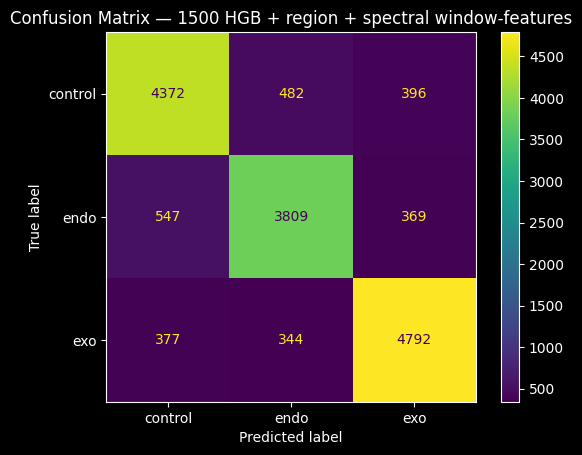

Permutation importance:


In [ ]:


# -------------------- 0) PATH --------------------
CSV_PATH = "mergedData/data_feat_1500_std.csv"

# -------------------- 1) LOAD --------------------
df0 = pd.read_csv(CSV_PATH)


wave_cols = [c for c in df0.columns if str(c).startswith("Wave_")]

def parse_wave(c):
    return float(str(c).split("_", 1)[1])

wave_axis = np.array([parse_wave(c) for c in wave_cols], dtype=float)
order = np.argsort(wave_axis)
wave_axis = wave_axis[order]
wave_cols = [wave_cols[i] for i in order]

df = df0
for c in wave_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["position", "class"] + wave_cols).reset_index(drop=True)

Xmat = df[wave_cols].to_numpy(dtype=float)
if not np.isfinite(Xmat).all():
    raise ValueError("В интенсивностях есть NaN/inf — сначала почистите данные.")

region = df["position"].astype(str).to_numpy()
y_str = df["class"].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)

print("Classes:", list(le.classes_))
print("Samples:", len(df), "| Spectrum points:", Xmat.shape[1], "| Unique regions:", len(np.unique(region)))

# -------------------- 2) FEATURE ENGINEERING FOR 1500 --------------------

F = df.drop(["position","class","group","nm","center","obj","power","during","acc","map","step","place","X","Y"], axis=1)

X_all = pd.concat([pd.DataFrame({"region": region}), F.reset_index(drop=True)], axis=1)
feat_names = F.columns.tolist()

print("Feature matrix:", F.shape)

# -------------------- 3) MODEL --------------------
pre = ColumnTransformer(
    transformers=[
        ("region_ohe", OneHotEncoder(handle_unknown="ignore"), ["region"]),
        ("spec", "passthrough", feat_names),
    ],
    remainder="drop",
)

model = Pipeline([
    ("pre", pre),
    ("clf", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        #max_depth=10,
        #learning_rate=0.02,
        max_iter=400,
        random_state=42
    ))
])

# -------------------- 6) Holdout --------------------
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.25, random_state=42, stratify=y)

model.fit(X_tr, y_tr)
pred = model.predict(X_te)

acc = accuracy_score(y_te, pred)
f1m = f1_score(y_te, pred, average="macro")
print("\nHoldout (stratified) metrics:")
print("Accuracy:", f"{acc:.6f}")
print("F1 macro:", f"{f1m:.6f}")
print(classification_report(y_te, pred, target_names=le.classes_))

cm = confusion_matrix(y_te, pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()
plt.title("Confusion Matrix — 1500 HGB + region + spectral window-features")
plt.show()

# -------------------- 7) Permutation importance --------------------
print("Permutation importance:")

perm = permutation_importance(
    model, X_te, y_te,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X_te.columns.to_list(),
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop-20 INPUT features by permutation importance:")
display(imp_df.head(20))

top = imp_df.head(20).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["importance_mean"])
plt.title("Permutation importance (top 20) — 1500")
plt.xlabel("Mean decrease in F1_macro after permutation")
plt.show()

In [2]:


# -------------------- 0) PATH --------------------
CSV_PATH = "mergedData/data_feat_1500_std.csv"

# -------------------- 1) LOAD --------------------
df0 = pd.read_csv(CSV_PATH)


wave_cols = [c for c in df0.columns if str(c).startswith("Wave_")]

def parse_wave(c):
    return float(str(c).split("_", 1)[1])

wave_axis = np.array([parse_wave(c) for c in wave_cols], dtype=float)
order = np.argsort(wave_axis)
wave_axis = wave_axis[order]
wave_cols = [wave_cols[i] for i in order]

df = df0
for c in wave_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["position", "class"] + wave_cols).reset_index(drop=True)

Xmat = df[wave_cols].to_numpy(dtype=float)
if not np.isfinite(Xmat).all():
    raise ValueError("В интенсивностях есть NaN/inf — сначала почистите данные.")

region = df["position"].astype(str).to_numpy()
y_str = df["class"].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)

print("Classes:", list(le.classes_))
print("Samples:", len(df), "| Spectrum points:", Xmat.shape[1], "| Unique regions:", len(np.unique(region)))

C:\Users\Zepspel\AppData\Local\Temp\ipykernel_11316\3021556552.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(CSV_PATH)


Classes: ['control', 'endo', 'exo']
Samples: 61950 | Spectrum points: 1015 | Unique regions: 7


In [ ]:
import joblib

MODEL_PATH = "hgb_raman_pipeline_1500.joblib"

joblib.dump({
    "model": model,
    "label_encoder": le,
    "wave_cols": wave_cols
}, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

In [22]:
from IPython.display import FileLink
FileLink("hgb_raman_pipeline_1500.joblib")

D:\hakaton\hgb_raman_pipeline_1500.joblib

In [23]:
import joblib

checkpoint = joblib.load("hgb_raman_pipeline_1500.joblib")

model2 = checkpoint["model"]
le = checkpoint["label_encoder"]
wave_cols = checkpoint["wave_cols"]

In [24]:
print(X_tr)

                 region  Wave_926.8  Wave_927.9  Wave_929.1  Wave_930.3  \
23012            cortex    0.027250    0.019023    0.031300    0.023674   
3400        cortex_left    0.021722    0.021810    0.023438    0.040841   
15738    striatum_right    0.008538    0.018772    0.022201    0.012628   
24869       cortex_left    0.026723    0.014928    0.002075    0.024292   
59366  cerebellum_right    0.023887   -0.002129    0.026781    0.006180   
...                 ...         ...         ...         ...         ...   
1201             cortex    0.022203    0.010777    0.012345    0.016189   
48575    striatum_right    0.011474    0.009063    0.018189    0.009787   
7600      striatum_left    0.013246    0.011695    0.008904    0.011899   
13948     striatum_left    0.037452    0.013823    0.016011   -0.006161   
54408    striatum_right    0.002161    0.014579    0.013603    0.024323   

       Wave_931.4  Wave_932.6  Wave_933.8  Wave_935.0  Wave_936.1  ...  \
23012    0.040181    0.01